In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cpu'

In [4]:
# Create dataset
materiales = pd.read_csv('./structuralparameters-vs-capacities-h2.csv')
materiales

,name,usablegc,usablevc,density,porosity,Ri,ssa,specific
0,cc2s/cc2hg088,4.78,0.0157,0.312,0.84,15.71,4751,2.692
1,cc2s/cc2hj8cp,3.23,0.0145,0.433,0.60,5.70,5445,1.384
2,cc2s/cc2j6dpv,1.64,0.0122,0.728,0.32,4.65,3195,0.440
3,jlu-mof108/dupver_P1,1.63,0.0134,0.813,0.44,4.71,2885,0.541
4,jlu-mof108/heffef_P1_charged,1.82,0.0136,0.733,0.46,4.77,3335,0.627
...,...,...,...,...,...,...,...,...
100,MOF-selected-poro-dens-NU2100/voxzep_P1,0.32,0.0072,2.260,0.14,5.31,456,0.062
101,mrts/mrt1,0.35,0.0044,1.250,0.06,2.43,882,0.048
102,mrts/mrt2,2.19,0.0125,0.559,0.50,5.79,3752,0.893
103,mrts/mrt3,0.02,0.0004,1.685,0.00,1.68,124,0.000


In [5]:
def remove_out_of_range(dataframe, column = 'column', minimum=0.0, maximum=1000.0):

    less_than = np.array(dataframe[column] < minimum)
    if np.sum(less_than) > 0:
        dataframe.drop(dataframe.loc[less_than].index, inplace=True)
    
    more_than = np.array(dataframe[column] > maximum)
    if np.sum(more_than) > 0:
        dataframe.drop(dataframe.loc[more_than].index, inplace=True)

    return dataframe

In [6]:
materiales_density = remove_out_of_range(materiales, column='density', minimum=0.001, maximum=3.0)
materiales.count()

name        105
usablegc    105
usablevc    105
density     105
porosity    105
Ri          105
ssa         105
specific    105
dtype: int64

In [7]:
materiales_porosity = remove_out_of_range(materiales_density, column='porosity', minimum=0.2, maximum=1.)
materiales.count()

name        72
usablegc    72
usablevc    72
density     72
porosity    72
Ri          72
ssa         72
specific    72
dtype: int64

In [8]:
materiales_Ri = remove_out_of_range(materiales_porosity, column='Ri', minimum=0.0, maximum=20.)
materiales.count()

name        72
usablegc    72
usablevc    72
density     72
porosity    72
Ri          72
ssa         72
specific    72
dtype: int64

In [9]:
materiales_ssa = remove_out_of_range(materiales_Ri, column='ssa', minimum=0.0, maximum=10000.)
materiales.count()

name        72
usablegc    72
usablevc    72
density     72
porosity    72
Ri          72
ssa         72
specific    72
dtype: int64

In [10]:
materiales_specific = remove_out_of_range(materiales_ssa, column='specific', minimum=0.0, maximum=2.)
materiales.count()

name        69
usablegc    69
usablevc    69
density     69
porosity    69
Ri          69
ssa         69
specific    69
dtype: int64

In [11]:
escala_x = MinMaxScaler()
escala_y = MinMaxScaler()

In [12]:
X_scaled = escala_x.fit_transform(np.array(materiales_specific.iloc[:, 1:3]))
Y_scaled = escala_y.fit_transform(np.array(materiales_specific.iloc[:, 3:]))

In [13]:
X_scaled

array([[0.78813559, 0.625     ],
       [0.33898305, 0.41964286],
       [0.33615819, 0.52678571],
       [0.38983051, 0.54464286],
       [0.44350282, 0.76785714],
       [0.41525424, 0.69642857],
       [0.34180791, 0.45535714],
       [0.45480226, 0.53571429],
       [0.64689266, 0.64285714],
       [0.40112994, 0.36607143],
       [0.25141243, 0.38392857],
       [0.56779661, 0.5625    ],
       [0.37570621, 0.51785714],
       [0.3559322 , 0.48214286],
       [0.83615819, 0.64285714],
       [0.35028249, 0.44642857],
       [0.35028249, 0.44642857],
       [0.37288136, 0.45535714],
       [0.3559322 , 0.44642857],
       [0.37288136, 0.47321429],
       [0.36723164, 0.46428571],
       [0.8079096 , 0.69642857],
       [0.76553672, 0.66964286],
       [0.78813559, 0.66071429],
       [0.35875706, 0.44642857],
       [0.35875706, 0.45535714],
       [0.9039548 , 0.72321429],
       [0.94915254, 0.66964286],
       [0.9519774 , 0.67857143],
       [0.99152542, 0.69642857],
       [0.

##### Y_scaled

In [14]:
class Data(Dataset):
  '''Dataset Class to store the samples and their corresponding labels, 
  and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.
  '''

  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:

    # need to convert float64 to float32 else 
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X.astype(np.float32)).to(device)
    self.y = torch.from_numpy(y.astype(np.float32)).to(device)
    self.len = self.X.shape[0]
  
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]

  def __len__(self) -> int:
    return self.len

In [15]:
# Generate the training dataset
traindata = Data(X_scaled, Y_scaled)

In [16]:
next(iter(traindata))

(tensor([0.7881, 0.6250]), tensor([0.0296, 0.7407, 0.3552, 1.0000, 0.7166]))

In [17]:
batch_size = 1
# tells the data loader instance how many sub-processes to use for data loading
# if the num_worker is zero (default) the GPU has to weight for CPU to load data
# Theoretically, greater the num_workers, 
# more efficiently the CPU load data and less the GPU has to wait
# num_workers = 32

# Load the training data into data loader with the 
# respective batch_size and num_workers
trainloader = DataLoader(traindata, batch_size=batch_size, shuffle=True)

testloader = DataLoader(traindata, batch_size=len(traindata))


In [18]:
class InverseRegression(nn.Module):
    '''Linear Regression Model
    '''

    def __init__(self, input_dim: int, hidden1_dim: int, hidden2_dim: int, output_dim: int) -> None:
        '''The network has 4 layers
             - input layer
             - hidden1 layer
             - hidden2 layer
             - output layer
        '''
        super(InverseRegression, self).__init__()
        self.act = nn.ReLU()
        self.input_to_hidden1 = nn.Linear(in_features=input_dim, out_features=hidden1_dim)
        self.hidden1_to_hidden2 = nn.Linear(in_features=hidden1_dim, out_features=hidden2_dim)
        self.hidden2_to_output = nn.Linear(in_features=hidden2_dim, out_features=output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # no activation and no softmax at the end
        x = self.act(self.input_to_hidden1(x))
        x = self.act(self.hidden1_to_hidden2(x))
        x = self.act(self.hidden2_to_output(x))
        return x

In [19]:
# number of features (len of X cols)
input_dim = X_scaled.shape[1]
# number of hidden layers
hidden_layers = 10
# output dimension is 1 because of linear regression
output_dim = Y_scaled.shape[1]
# initiate the linear regression model
model = InverseRegression(input_dim=input_dim, hidden1_dim=10, hidden2_dim=5, output_dim=output_dim).to(device)
print(model)

InverseRegression(
  (act): ReLU()
  (input_to_hidden1): Linear(in_features=2, out_features=10, bias=True)
  (hidden1_to_hidden2): Linear(in_features=10, out_features=5, bias=True)
  (hidden2_to_output): Linear(in_features=5, out_features=5, bias=True)
)


In [20]:
summary(model=model, input_data=(1,2))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 10]               30
├─ReLU: 1-2                              [-1, 1, 10]               --
├─Linear: 1-3                            [-1, 1, 5]                55
├─ReLU: 1-4                              [-1, 1, 5]                --
├─Linear: 1-5                            [-1, 1, 5]                30
├─ReLU: 1-6                              [-1, 1, 5]                --
Total params: 115
Trainable params: 115
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 10]               30
├─ReLU: 1-2                              [-1, 1, 10]               --
├─Linear: 1-3                            [-1, 1, 5]                55
├─ReLU: 1-4                              [-1, 1, 5]                --
├─Linear: 1-5                            [-1, 1, 5]                30
├─ReLU: 1-6                              [-1, 1, 5]                --
Total params: 115
Trainable params: 115
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [21]:
# criterion to computes the loss between input and target
criterion = nn.MSELoss()
# optimizer that will be used to update weights and biases
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [22]:
trainingloss = []

In [23]:
epochs = 100
for epoch in tqdm(range(epochs)):
    model.train()
    for (inputs, labels) in trainloader:
        # inputs, labels = data

        # forward propagation
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # set optimizer to zero grad 
        # to remove previous epoch gradients
        optimizer.zero_grad()

        # backward propagation
        loss.backward()

        # optimize
        optimizer.step()
    model.eval()
    X_test, y_test = next(iter(testloader))
    trainingloss.append(criterion(model(X_test), y_test).item())

100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 34.55it/s]


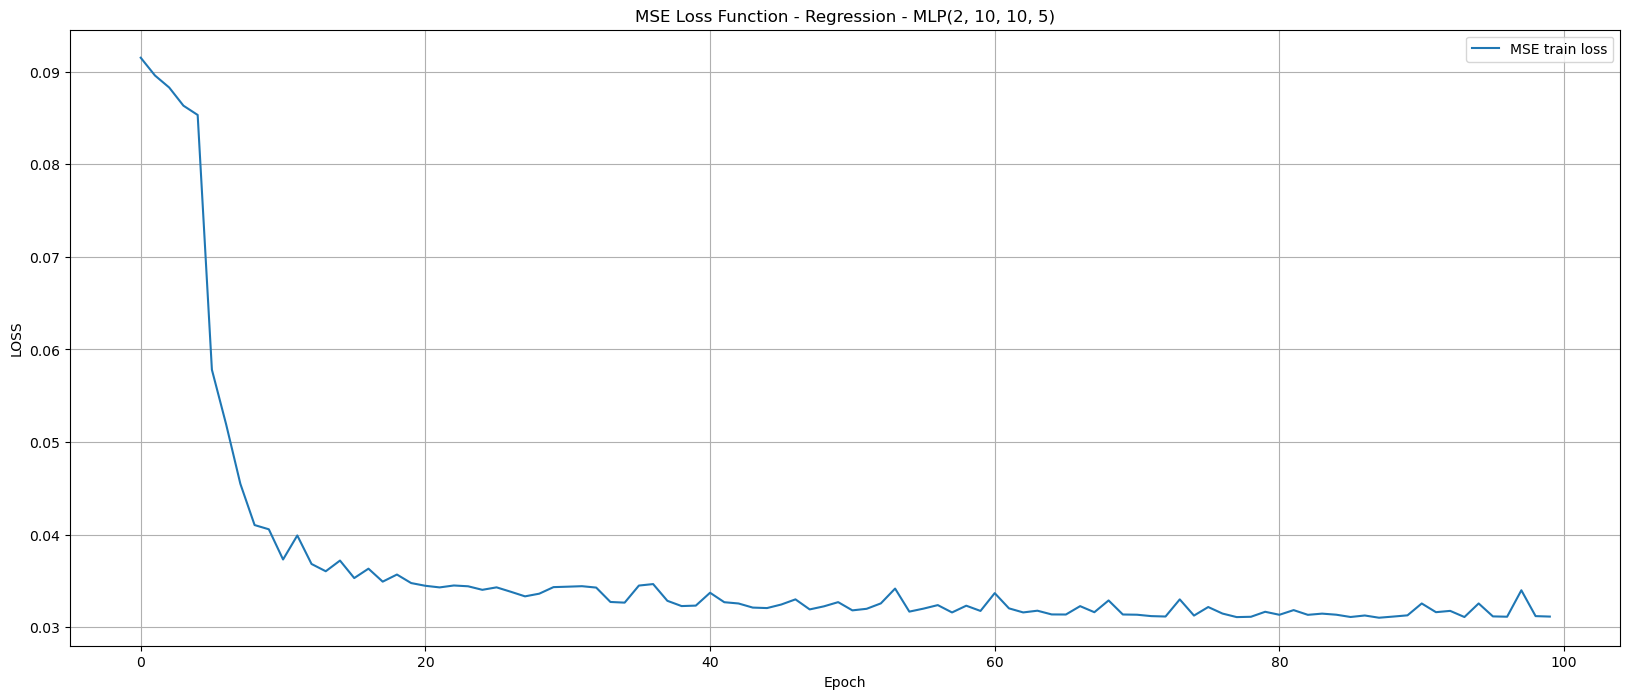

In [24]:
fig, ax = plt.subplots(figsize=(20,8))


ax.plot(trainingloss, label='MSE train loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('LOSS')
ax.legend()
ax.grid()
ax.set_title("MSE Loss Function - Regression - MLP(2, 10, 10, 5)")

plt.show()

In [25]:
x1 = torch.from_numpy(escala_x.transform(np.array([5.5, 0.040]).reshape(1,2))).to(torch.float32).to(device)
x1

tensor([[1.4294, 2.9018]])

In [26]:
model(x1).detach().numpy()

array([[0.       , 0.9143374, 0.8238393, 1.0238639, 0.994473 ]],
      dtype=float32)

In [27]:
escala_y.data_min_, escala_y.data_max_

(array([3.73e-01, 2.00e-01, 2.83e+00, 7.88e+02, 9.20e-02]),
 array([2.399e+00, 7.400e-01, 1.091e+01, 5.445e+03, 1.895e+00]))

In [28]:
def desescala(x, data_max, data_min):
    return [(x[i]*(data_max[i]-data_min[i]))+data_min[i] for i in range(data_max.shape[0])]

In [29]:
escala_y.data_min_.shape[0]

5

In [30]:
desescala(model(x1).detach().numpy().reshape(-1,), escala_y.data_max_, escala_y.data_min_)

[0.373,
 0.6937421941757203,
 9.486621599197388,
 5556.134236454964,
 1.8850347838401795]